In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
space_titanic_data = pd.read_csv("/Users/archisha/Documents/GitHub/lookify_current_2.0/Spaceship-Titanic-Survival-Prediction/train (2).csv")

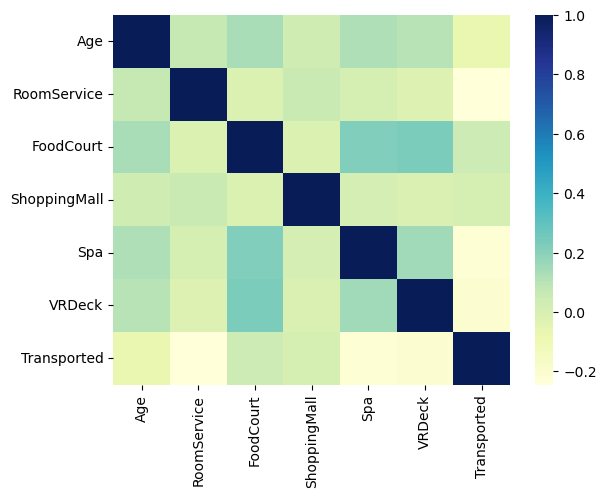

In [22]:
sns.heatmap(space_titanic_data.corr(numeric_only=True), cmap='YlGnBu')
plt.show()

In [23]:
space_titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [24]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42) # Leaves 20% of data for testing and 80% for training

for train_indices, test_indices in split.split(space_titanic_data, space_titanic_data[["Transported"]]):
    strat_train_set = space_titanic_data.iloc[train_indices]
    strat_test_set = space_titanic_data.iloc[test_indices]

In [25]:
from sklearn.base import BaseEstimator, TransformerMixin # parameter management and provides a fit_transform method
from sklearn.preprocessing import OneHotEncoder

SPEND = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
NUMERIC = ["Age"] + SPEND
CATEGORICAL = ["HomePlanet", "CryoSleep", "Destination", "VIP", "Deck", "Side"]

class FeatureExtractor(BaseEstimator, TransformerMixin):
    """Pulls the information hiding inside the text columns"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # "B/0/P" -> deck B, cabin number 0, port side. Deck and side both matter.
        cabin = X["Cabin"].str.split("/", expand=True)
        X["Deck"] = cabin[0]
        X["CabinNum"] = pd.to_numeric(cabin[1], errors="coerce")
        X["Side"] = cabin[2]

        # "0003_02" -> passenger 2 of group 3
        group = X["PassengerId"].str.split("_", expand=True)[0]
        X["GroupSize"] = group.map(group.value_counts())

        asleep = X["CryoSleep"] == True
        for column in SPEND:
            X.loc[asleep & X[column].isna(), column] = 0.0

        return X

In [ ]:
from sklearn.impute import SimpleImputer # how to fill in missing values

class MissingValueImputer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        # Median instead of mean
        self.numeric_imputer = SimpleImputer(strategy="median").fit(X[NUMERIC + ["CabinNum", "GroupSize"]])
        
        self.categorical_imputer = SimpleImputer(strategy="most_frequent").fit(X[CATEGORICAL])
        return self

    def transform(self, X):
        X = X.copy()
        numeric = NUMERIC + ["CabinNum", "GroupSize"]
        X[numeric] = self.numeric_imputer.transform(X[numeric])
        X[CATEGORICAL] = self.categorical_imputer.transform(X[CATEGORICAL])
        return X

class SpendFeatures(BaseEstimator, TransformerMixin):
    """Runs after imputation"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["TotalSpend"] = X[SPEND].sum(axis=1)
        # Spending nothing at all is a strong marker 
        X["NoSpend"] = (X["TotalSpend"] == 0).astype(int)

        for column in SPEND + ["TotalSpend"]:
            X[column] = np.log1p(X[column])

        return X

In [27]:
class FeatureEncoder(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        # Fit once on the training data so the test set gets the exact same columns
        self.encoder = OneHotEncoder(handle_unknown="ignore").fit(X[CATEGORICAL])
        return self

    def transform(self, X):
        X = X.copy()
        matrix = self.encoder.transform(X[CATEGORICAL]).toarray()

        column_names = self.encoder.get_feature_names_out(CATEGORICAL)

        for i in range(len(matrix.T)): # iterates through transposed matrix
            X[column_names[i]] = matrix.T[i]

        return X

In [28]:
class FeatureDropper(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # The raw categoricals are redundant now that they're one-hot encoded, and PassengerId/Name/Cabin have already been mined for everything useful
        return X.drop(CATEGORICAL + ["PassengerId", "Name", "Cabin"], axis=1, errors="ignore")

In [29]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([("featureextractor", FeatureExtractor()),
                     ("imputer", MissingValueImputer()),
                     ("spendfeatures", SpendFeatures()),
                     ("featureencoder", FeatureEncoder()),
                     ("featuredropper", FeatureDropper())])

In [30]:
# fit_transform on train
X_train = pipeline.fit_transform(strat_train_set.drop("Transported", axis=1))
y_train = strat_train_set["Transported"]

X_test = pipeline.transform(strat_test_set.drop("Transported", axis=1))
y_test = strat_test_set["Transported"]

print(X_train.shape, X_test.shape)
print("missing values:", X_train.isna().sum().sum())

(6954, 30) (1739, 30)
missing values: 0


In [31]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Compare candidates with cross-validation on the TRAINING set only
candidates = {
    "LogisticRegression": Pipeline([("scaler", StandardScaler()),
                                    ("clf", LogisticRegression(max_iter=2000))]),
    "RandomForest": RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                           random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=400,
                                                           learning_rate=0.06,
                                                           max_leaf_nodes=31,
                                                           l2_regularization=1.0,
                                                           early_stopping=True,
                                                           random_state=42),
}

for name, model in candidates.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1)
    print(f"{name:<22} {scores.mean():.4f}")

LogisticRegression     0.7725
RandomForest           0.8018
HistGradientBoosting   0.8076


In [33]:
from sklearn.model_selection import GridSearchCV

clf = HistGradientBoostingClassifier(max_iter=400, early_stopping=True, random_state=42)

param_grid = [
    {"learning_rate": [0.03, 0.06, 0.1],
     "max_leaf_nodes": [15, 31, 63],
     "min_samples_leaf": [20, 40]}
]

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring="accuracy", return_train_score=True, n_jobs=-1) # cv = number of folds
grid_search.fit(X_train, y_train)

print(f"best CV accuracy: {grid_search.best_score_:.4f}")
print(grid_search.best_params_)

best CV accuracy: 0.8100
{'learning_rate': 0.1, 'max_leaf_nodes': 15, 'min_samples_leaf': 20}


In [34]:
final_clf = grid_search.best_estimator_

In [35]:
final_clf

HistGradientBoostingClassifier(early_stopping=True, max_iter=400,
                               max_leaf_nodes=15, random_state=42)

test accuracy: 0.8102

              precision    recall  f1-score   support

       False       0.81      0.81      0.81       863
        True       0.81      0.81      0.81       876

    accuracy                           0.81      1739
   macro avg       0.81      0.81      0.81      1739
weighted avg       0.81      0.81      0.81      1739



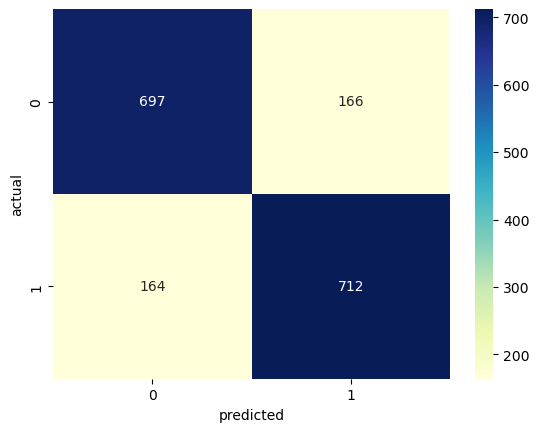

In [36]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

predictions = final_clf.predict(X_test)

print(f"test accuracy: {accuracy_score(y_test, predictions):.4f}\n")
print(classification_report(y_test, predictions))

sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt="d", cmap="YlGnBu")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

In [37]:
from sklearn.base import clone

# Refit on all 8693 rows
production_pipeline = clone(pipeline)
production_model = HistGradientBoostingClassifier(max_iter=400, early_stopping=True,
                                                  random_state=42, **grid_search.best_params_)

X_full = production_pipeline.fit_transform(space_titanic_data.drop("Transported", axis=1))
y_full = space_titanic_data["Transported"]

production_model.fit(X_full, y_full)
print(f"trained on {X_full.shape[0]} rows, {X_full.shape[1]} features")

trained on 8693 rows, 30 features


In [38]:
competition_test_data = pd.read_csv("/Users/archisha/Documents/GitHub/lookify_current_2.0/Spaceship-Titanic-Survival-Prediction/test (1).csv")

# medians and categories learned from the training set
X_competition = production_pipeline.transform(competition_test_data)

assert list(X_competition.columns) == list(X_full.columns), "feature columns drifted"

submission = pd.DataFrame({
    "PassengerId": competition_test_data["PassengerId"],
    "Transported": production_model.predict(X_competition).astype(bool),
})

submission.to_csv("submission.csv", index=False)

print(submission.shape)
print(submission["Transported"].value_counts(normalize=True).round(3).to_string())
submission.head()

(4277, 2)
Transported
True     0.523
False    0.477


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
